<a href="https://colab.research.google.com/github/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/blob/main/PERFORMANCE_LOGISTIC__REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Linear Regression Recap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Import the Dataset: AoA vs stall.csv
aircraft=pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/refs/heads/main/linear%20vs%20logistic%20_Product_sales.csv")

In [ ]:
import sklearn as sk
from sklearn import linear_model
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(aircraft[["AOA"]], aircraft[["STALL_OR_NOSTALL"]])


LinearRegression()

In [ ]:
print("intercept",lr.intercept_)
print("Co-efficient",lr.coef_)

intercept [-0.17493853]
Co-efficient [[0.02102409]]


In [ ]:
#If AOA is 4, then,  will AIRCRFAT STALL?
predict1 = lr.predict([[4]])
print(predict1)

# THE ABOVE CAN BE WRITE IN FOLLOWING WAY
d1=pd.DataFrame({"AOA":[4]})
predict1=lr.predict(d1)
print(predict1)


[[-0.09084219]]
[[-0.09084219]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#If AOA is 105, then,  will AIRCRFAT STALL?
predict2 = lr.predict([[105]])
print(predict2)

[[2.03259042]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:

# Predict values
y_pred = lr.predict(aircraft[["AOA"]])

# Calculate R²
r2 = r2_score(aircraft["STALL_OR_NOSTALL"], y_pred)
print("R-squared:", r2)                           # THOUGH ITS SHOWING GOOD R2, BUT ITS INVALID.

R-squared: 0.8496458586530549


## Drawing Linear Regression line

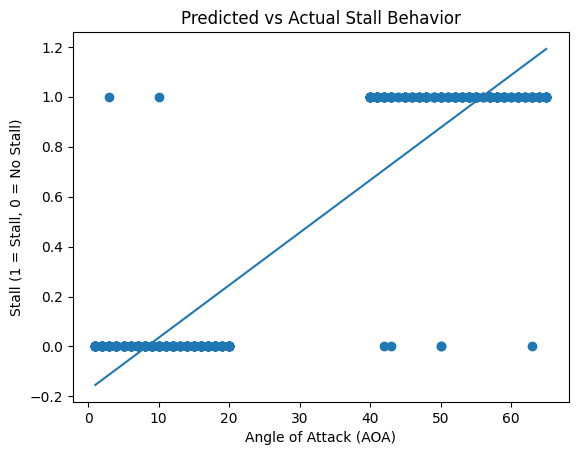

In [ ]:
# 1. Fit Linear Regression Model
lr = LinearRegression()
lr.fit(aircraft[["AOA"]], aircraft["STALL_OR_NOSTALL"])

# 2. Add predicted stall directly inside aircraft df
aircraft["PRED_STALL"] = lr.predict(aircraft[["AOA"]])

# 3. Sort for smooth line in graph: SORT is to prevent the LINE PLOT from zig-zagging (random order)
aircraft = aircraft.sort_values("AOA")

# 4. Plot Actual vs Predicted
plt.scatter(aircraft["AOA"], aircraft["STALL_OR_NOSTALL"])     # Actual stall
plt.plot(aircraft["AOA"], aircraft["PRED_STALL"])              # Predicted stall

# 5. Labels
plt.title("Predicted vs Actual Stall Behavior")
plt.xlabel("Angle of Attack (AOA)")
plt.ylabel("Stall (1 = Stall, 0 = No Stall)")
plt.show()

# Scatter plot = Actual AoA vs Actual Stall
# Line plot = Actual AoA vs Predicted Stall


# Logistic Regression

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# Logistic Regression: AOA vs STALL_OR_NOSTALL
logistic = LogisticRegression()
logistic.fit(aircraft[["AOA"]], aircraft["STALL_OR_NOSTALL"])

print("Intercept", logistic.intercept_)
print("Coefficient", logistic.coef_)

# If AOA is 4°, will the aircraft stall?
predict1 = logistic.predict([[4]])
print("Prediction for AOA = 4°:", predict1)


# If AOA is 105°, will the aircraft stall?
predict2 = logistic.predict([[62]])
print("Prediction for AOA = 105° :", predict2)




Intercept [-7.33527311]
Coefficient [[0.22805012]]
Prediction for AOA = 4°: [0]
Prediction for AOA = 105° : [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


## Drawing Logistic Regression line

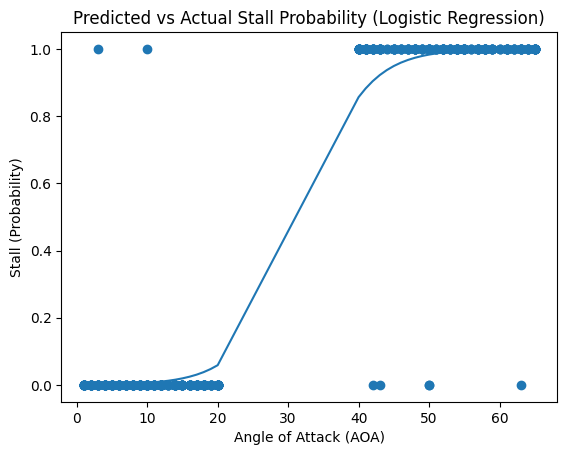

In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 1. Fit Logistic Regression Model
logistic = LogisticRegression()
logistic.fit(aircraft[["AOA"]], aircraft["STALL_OR_NOSTALL"])

# 2. Add predicted stall probability directly inside aircraft df
#    logistic.predict_proba gives two columns: [No stall probability, Stall probability]
aircraft["PRED_STALL_PROB"] = logistic.predict_proba(aircraft[["AOA"]])[:,1]


# 3. Sort for smooth line in graph (prevents zig-zag in logistic curve)
aircraft = aircraft.sort_values("AOA")

# 4. Plot Actual vs Predicted Probability
plt.scatter(aircraft["AOA"], aircraft["STALL_OR_NOSTALL"])          # Actual stall (0 or 1)
plt.plot(aircraft["AOA"], aircraft["PRED_STALL_PROB"])              # Predicted stall probability (S-curve)

# 5. Labels
plt.title("Predicted vs Actual Stall Probability (Logistic Regression)")
plt.xlabel("Angle of Attack (AOA)")
plt.ylabel("Stall (Probability)")

plt.show()

# Scatter plot  = Actual AoA vs Actual Stall
# Line plot     = Actual AoA vs Predicted Stall Probability


# Multiple Logistic Regression

In [ ]:
AIRCRAFT_MISSION = pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/refs/heads/main/logistic%20_regression.csv")


In [ ]:
AIRCRAFT_MISSION.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   MISSION_SUCCESS             100000 non-null  int64
 1   AIRCRAFT_WEIGHT             100000 non-null  int64
 2   AIRFRAME_HOURS              100000 non-null  int64
 3   MAINTENANCE_DEFECTS         100000 non-null  int64
 4   CONFIG_CHANGES              100000 non-null  int64
 5   WEATHER_CONDITION           100000 non-null  int64
 6   MISSION_FUEL_LOAD           100000 non-null  int64
 7   ENGINE_FAULTS_PER_MONTH     100000 non-null  int64
 8   AIRCRAFT_PERFORMANCE_SCORE  100000 non-null  int64
dtypes: int64(9)
memory usage: 6.9 MB


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create logistic regression model
logistic1 = LogisticRegression()

# Fit the model for MISSION_SUCCESS based on all other variables
logistic1.fit( AIRCRAFT_MISSION[[ "AIRCRAFT_WEIGHT","AIRFRAME_HOURS","MAINTENANCE_DEFECTS","CONFIG_CHANGES","WEATHER_CONDITION","MISSION_FUEL_LOAD","ENGINE_FAULTS_PER_MONTH","AIRCRAFT_PERFORMANCE_SCORE"]],AIRCRAFT_MISSION[["MISSION_SUCCESS"]])



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Print model parameters
print("Intercept:", logistic1.intercept_)
print("Coefficients:", logistic1.coef_)

Intercept: [-0.01100601]
Coefficients: [[ 3.71249380e-05  2.55962690e-02  7.37975743e-01 -2.63294380e-01
  -1.42452436e-01  7.87918595e-05 -2.64241712e-01 -7.63137265e-02]]


# Confusion Matrix & Accuracy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Predict using the logistic regression model
predict1 = logistic1.predict(
    AIRCRAFT_MISSION[[
        "AIRCRAFT_WEIGHT",
        "AIRFRAME_HOURS",
        "MAINTENANCE_DEFECTS",
        "CONFIG_CHANGES",
        "WEATHER_CONDITION",
        "MISSION_FUEL_LOAD",
        "ENGINE_FAULTS_PER_MONTH",
        "AIRCRAFT_PERFORMANCE_SCORE"
    ]]
)

print(predict1)

# 2. Confusion Matrix
cm1 = confusion_matrix(AIRCRAFT_MISSION[['MISSION_SUCCESS']], predict1)
print("Confusion Matrix:")
print(cm1)

# 3. Total samples
print("col sums", sum(cm1))
total1=sum(sum(cm1))
print("Total", total1)

# 4. Accuracy
accuracy1 = (cm1[0,0] + cm1[1,1]) / total1
print("\nAccuracy:", accuracy1)

#INSTEAD OF DOING MANUAL , WE CAN GET ACCURACY DIRECTLY

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(AIRCRAFT_MISSION["MISSION_SUCCESS"], predict1)
print("Accuracy:", accuracy)


[1 1 0 ... 1 1 1]
Confusion Matrix:
[[33852  8289]
 [ 6143 51716]]
col sums [39995 60005]
Total 100000

Accuracy: 0.85568
Accuracy: 0.85568


# Multicollinearity

In [ ]:
import statsmodels.formula.api as sm

def vif_cal(input_data, dependent_col):
    x_vars=input_data.drop([dependent_col], axis=1)
    xvar_names=x_vars.columns
    for i in range(0,xvar_names.shape[0]):
        y=x_vars[xvar_names[i]]
        x=x_vars[xvar_names.drop(xvar_names[i])]
        rsq=sm.ols(formula="y~x", data=x_vars).fit().rsquared
        vif=round(1/(1-rsq),2)
        print (xvar_names[i], " VIF = " , vif)

In [ ]:
vif_cal(input_data=AIRCRAFT_MISSION, dependent_col="MISSION_SUCCESS")

AIRCRAFT_WEIGHT  VIF =  1.02
AIRFRAME_HOURS  VIF =  1.04
MAINTENANCE_DEFECTS  VIF =  1.17
CONFIG_CHANGES  VIF =  11.98
WEATHER_CONDITION  VIF =  1.61
MISSION_FUEL_LOAD  VIF =  1.0
ENGINE_FAULTS_PER_MONTH  VIF =  11.44
AIRCRAFT_PERFORMANCE_SCORE  VIF =  1.14


In [ ]:
#Drop the variable with highest VIF
vif_cal(input_data=AIRCRAFT_MISSION.drop("CONFIG_CHANGES", axis=1), dependent_col="MISSION_SUCCESS")

AIRCRAFT_WEIGHT  VIF =  1.02
AIRFRAME_HOURS  VIF =  1.04
MAINTENANCE_DEFECTS  VIF =  1.17
WEATHER_CONDITION  VIF =  1.55
MISSION_FUEL_LOAD  VIF =  1.0
ENGINE_FAULTS_PER_MONTH  VIF =  1.49
AIRCRAFT_PERFORMANCE_SCORE  VIF =  1.14


# Individual Impact of Variables

In [ ]:
import statsmodels.api as sm

m1 = sm.Logit(
    AIRCRAFT_MISSION["MISSION_SUCCESS"],
    AIRCRAFT_MISSION[[
        "AIRCRAFT_WEIGHT",
        "AIRFRAME_HOURS",
        "MAINTENANCE_DEFECTS",
        "WEATHER_CONDITION",
        "MISSION_FUEL_LOAD",
        "ENGINE_FAULTS_PER_MONTH",
        "AIRCRAFT_PERFORMANCE_SCORE"
    ]]
)

model_result = m1.fit()
print(model_result.summary())



Optimization terminated successfully.
         Current function value: 0.297056
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        MISSION_SUCCESS   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99993
Method:                           MLE   Df Model:                            6
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.5636
Time:                        11:12:01   Log-Likelihood:                -29706.
converged:                       True   LL-Null:                       -68074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
AIRCRAFT_WEIGHT             2.691e-05   9.68e-06      2.781      0.005    7.

In [ ]:
import statsmodels.api as sm
 # DROP THE VARIABLE WITH HIGH P VALUE
m1 = sm.Logit(
    AIRCRAFT_MISSION["MISSION_SUCCESS"],
    AIRCRAFT_MISSION[[
        "AIRCRAFT_WEIGHT",
        "AIRFRAME_HOURS",
        "MAINTENANCE_DEFECTS",
        "WEATHER_CONDITION",
        "ENGINE_FAULTS_PER_MONTH",
        "AIRCRAFT_PERFORMANCE_SCORE"
    ]]
)

model_result = m1.fit()
print(model_result.summary())

Optimization terminated successfully.
         Current function value: 0.297061
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        MISSION_SUCCESS   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99994
Method:                           MLE   Df Model:                            5
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.5636
Time:                        11:12:03   Log-Likelihood:                -29706.
converged:                       True   LL-Null:                       -68074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
AIRCRAFT_WEIGHT              2.58e-05   8.76e-06      2.946      0.003    8.

# Rank Ordering of the impactful variables

In [ ]:
import statsmodels.api as sm
# SEE THE Z SQUARE VALUE(WAL CHI-SQUARE)
m1 = sm.Logit(
    AIRCRAFT_MISSION["MISSION_SUCCESS"],
    AIRCRAFT_MISSION[[
        "AIRCRAFT_WEIGHT",
        "AIRFRAME_HOURS",
        "MAINTENANCE_DEFECTS",
        "WEATHER_CONDITION",
        "ENGINE_FAULTS_PER_MONTH",
        "AIRCRAFT_PERFORMANCE_SCORE"
    ]]
)

model_result = m1.fit()
print(model_result.summary())

Optimization terminated successfully.
         Current function value: 0.297061
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        MISSION_SUCCESS   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99994
Method:                           MLE   Df Model:                            5
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.5636
Time:                        11:12:05   Log-Likelihood:                -29706.
converged:                       True   LL-Null:                       -68074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
AIRCRAFT_WEIGHT              2.58e-05   8.76e-06      2.946      0.003    8.

# ***CROSS VALIDATION- TRAIN AND TEST DATA***





In [ ]:
import pandas as pd
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score




# --------------------------------------------------------
# 1. TRAIN–TEST SPLIT
# --------------------------------------------------------
train_data, test_data = model_selection.train_test_split(
    AIRCRAFT_MISSION,
    test_size=0.2,
    random_state=42   # for reproducibility
)

print("Train Data Shape ", train_data.shape)
print("Test Data Shape  ", test_data.shape)

# --------------------------------------------------------
# 2. CREATE LOGISTIC REGRESSION MODEL
# --------------------------------------------------------
logistic2 = LogisticRegression(max_iter=200)

# Fit the model for MISSION_SUCCESS on all 8 predictors
logistic2.fit(
    train_data[[
        "AIRCRAFT_WEIGHT",
        "AIRFRAME_HOURS",
        "MAINTENANCE_DEFECTS",
        "WEATHER_CONDITION",
        "ENGINE_FAULTS_PER_MONTH",
        "AIRCRAFT_PERFORMANCE_SCORE"
    ]],
    train_data[["MISSION_SUCCESS"]]
)

# --------------------------------------------------------
# 3. ACCURACY ON TRAIN DATA
# --------------------------------------------------------
train_pred = logistic2.predict(
    train_data[[
      "AIRCRAFT_WEIGHT",
        "AIRFRAME_HOURS",
        "MAINTENANCE_DEFECTS",
        "WEATHER_CONDITION",
        "ENGINE_FAULTS_PER_MONTH",
        "AIRCRAFT_PERFORMANCE_SCORE"
    ]]
)

# Confusion Matrix — Train
cm_train = confusion_matrix(train_data["MISSION_SUCCESS"], train_pred)
print("\nConfusion Matrix (Train):\n", cm_train)

# Manual Accuracy (Train)
accuracy_train_manual = (cm_train[0,0] + cm_train[1,1]) / cm_train.sum()
print("Manual Accuracy (Train):", accuracy_train_manual)

# Direct accuracy_score — Train
accuracy_train_direct = accuracy_score(train_data["MISSION_SUCCESS"], train_pred)
print("Direct Accuracy (Train):", accuracy_train_direct)

# --------------------------------------------------------
# 4. ACCURACY ON TEST DATA
# --------------------------------------------------------
test_pred = logistic2.predict(
    test_data[[
       "AIRCRAFT_WEIGHT",
        "AIRFRAME_HOURS",
        "MAINTENANCE_DEFECTS",
        "WEATHER_CONDITION",
        "ENGINE_FAULTS_PER_MONTH",
        "AIRCRAFT_PERFORMANCE_SCORE"
    ]]
)

# Confusion Matrix — Test
cm_test = confusion_matrix(test_data["MISSION_SUCCESS"], test_pred)
print("\nConfusion Matrix (Test):\n", cm_test)

# Manual Accuracy (Test)
accuracy_test_manual = (cm_test[0,0] + cm_test[1,1]) / cm_test.sum()
print("Manual Accuracy (Test):", accuracy_test_manual)

# Direct accuracy_score — Test
accuracy_test_direct = accuracy_score(test_data["MISSION_SUCCESS"], test_pred)
print("Direct Accuracy (Test):", accuracy_test_direct)


Train Data Shape  (80000, 9)
Test Data Shape   (20000, 9)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Confusion Matrix (Train):
 [[27526  6197]
 [ 4516 41761]]
Manual Accuracy (Train): 0.8660875
Direct Accuracy (Train): 0.8660875

Confusion Matrix (Test):
 [[ 6797  1621]
 [ 1111 10471]]
Manual Accuracy (Test): 0.8634
Direct Accuracy (Test): 0.8634


# ***PREDICTION FOR NEW INPUT***

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score

# --------------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------------
AIRCRAFT_MISSION = pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/refs/heads/main/logistic%20_regression.csv")

# --------------------------------------------------------
# 2. SELECT FINAL 6 VARIABLES (based on VIF + p-values)
# --------------------------------------------------------
X = AIRCRAFT_MISSION[[
    "AIRCRAFT_WEIGHT",
    "AIRFRAME_HOURS",
    "MAINTENANCE_DEFECTS",
    "WEATHER_CONDITION",
    "ENGINE_FAULTS_PER_MONTH",
    "AIRCRAFT_PERFORMANCE_SCORE"
]]

y = AIRCRAFT_MISSION["MISSION_SUCCESS"]

# --------------------------------------------------------
# 3. FIT LOGISTIC REGRESSION (statsmodels Logit)
# --------------------------------------------------------
m1 = sm.Logit(y, X)
model_result = m1.fit()

# Print regression summary
print(model_result.summary())



# --------------------------------------------------------
# 4. CONFUSION MATRIX & ACCURACY (FOR FULL DATASET)
# --------------------------------------------------------
# Predict for ALL rows in dataset
y_pred_all = model_result.predict(X)

# Convert probabilities to 0/1 using threshold 0.5
y_pred_class = (y_pred_all > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y, y_pred_class)
print("\nConfusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y, y_pred_class)
print("\nAccuracy =", acc)


# --------------------------------------------------------
# 5. PREDICTING MISSION SUCCESS FOR NEW INPUT
# --------------------------------------------------------
new_case = pd.DataFrame({
    "AIRCRAFT_WEIGHT": [1590],
    "AIRFRAME_HOURS": [82],
    "MAINTENANCE_DEFECTS": [6],
    "WEATHER_CONDITION": [1],
    "ENGINE_FAULTS_PER_MONTH": [3],
    "AIRCRAFT_PERFORMANCE_SCORE": [55]
})

# Predict probability
prob = model_result.predict(new_case)
print("\nMission Success Probability =", prob.values[0])

# Predict 0 or 1
prediction = 1 if prob.values[0] > 0.5 else 0
print("Mission Success Prediction (0=Fail, 1=Success) =", prediction)

Optimization terminated successfully.
         Current function value: 0.297061
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:        MISSION_SUCCESS   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99994
Method:                           MLE   Df Model:                            5
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.5636
Time:                        11:12:14   Log-Likelihood:                -29706.
converged:                       True   LL-Null:                       -68074.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
AIRCRAFT_WEIGHT              2.58e-05   8.76e-06      2.946      0.003    8.

# ***Multiple Logistic Regression-R/C- EXAMPLE 2***

In [ ]:
# CHECK WHEATRE AIRCRTAFT WILL CLIMB OR NOT.
# 1 - CLIMB
# 0 -  NOT CLIMB
RATE_OF_CLIMB = pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/refs/heads/main/RATE_OF_CLIMB.csv")
RATE_OF_CLIMB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57600 entries, 0 to 57599
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RHO     57600 non-null  float64
 1   W       57600 non-null  int64  
 2   V       57600 non-null  int64  
 3   RC      57600 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 1.8 MB


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

# --------------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------------
RATE_OF_CLIMB = pd.read_csv("https://raw.githubusercontent.com/cmvigneswaranaero-gif/AC_PERFROMANCE_WITH_ML/refs/heads/main/RATE_OF_CLIMB.csv")
RATE_OF_CLIMB.info()

# --------------------------------------------------------
# 2. SELECT INPUTS (X) AND OUTPUT (y)
# --------------------------------------------------------
X = RATE_OF_CLIMB[["RHO", "W", "V"]]   # Independent variables
y = RATE_OF_CLIMB["RC"]                # RC is already 0 or 1 (Climb Success)

# --------------------------------------------------------
# 3. FIT LOGISTIC REGRESSION
# --------------------------------------------------------
logistic_model = LogisticRegression(max_iter=5000)
logistic_model.fit(X, y)

print("Intercept:", logistic_model.intercept_)
print("Coefficients:", logistic_model.coef_)

# --------------------------------------------------------
# 4. PREDICT FOR FULL DATASET
# --------------------------------------------------------
y_pred = logistic_model.predict(X)

# --------------------------------------------------------
# 5. CONFUSION MATRIX + ACCURACY
# --------------------------------------------------------
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

print("\nConfusion Matrix:\n", cm)
print("\nAccuracy:", accuracy)

# --------------------------------------------------------
# 6. PREDICT CLIMB SUCCESS FOR NEW AIRCRAFT DATA
# --------------------------------------------------------
new_case = pd.DataFrame({
    "RHO": [1.12],    # example values
    "W":   [15000],
    "V":   [75]
})

prob = logistic_model.predict_proba(new_case)[:,1][0]
print("\nClimb Success Probability =", prob)

prediction = 1 if prob > 0.5 else 0
print("Climb Success Prediction (0=Fail, 1=Success) =", prediction)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57600 entries, 0 to 57599
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RHO     57600 non-null  float64
 1   W       57600 non-null  int64  
 2   V       57600 non-null  int64  
 3   RC      57600 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 1.8 MB
Intercept: [4.30800813]
Coefficients: [[-1.66382407e+00 -2.54833950e-06 -1.14186774e-02]]

Confusion Matrix:
 [[19595  6864]
 [ 6250 24891]]

Accuracy: 0.7723263888888889

Climb Success Probability = 0.8248991837125373
Climb Success Prediction (0=Fail, 1=Success) = 1


# ****INDIVIDUAL VARIABLE IMPACT****

In [ ]:
import statsmodels.api as sm

m2 = sm.Logit(
    RATE_OF_CLIMB["RC"],
    RATE_OF_CLIMB[[
        "RHO"
        , "W"
        , "V"
    ]]
)

model_result_rc = m2.fit()
print(model_result_rc.summary())


Optimization terminated successfully.
         Current function value: 0.601859
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                     RC   No. Observations:                57600
Model:                          Logit   Df Residuals:                    57597
Method:                           MLE   Df Model:                            2
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.1275
Time:                        11:12:17   Log-Likelihood:                -34667.
converged:                       True   LL-Null:                       -39735.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
RHO            0.4364      0.023     18.717      0.000       0.391       0.482
W           9.071e-06   1.64e

# ***MULTICOLINEARITY***

In [ ]:
import statsmodels.formula.api as sm

def vif_cal(input_data, dependent_col):
    x_vars=input_data.drop([dependent_col], axis=1)
    xvar_names=x_vars.columns
    for i in range(0,xvar_names.shape[0]):
        y=x_vars[xvar_names[i]]
        x=x_vars[xvar_names.drop(xvar_names[i])]
        rsq=sm.ols(formula="y~x", data=x_vars).fit().rsquared
        vif=round(1/(1-rsq),2)
        print (xvar_names[i], " VIF = " , vif)

In [ ]:
vif_cal(input_data=RATE_OF_CLIMB, dependent_col="RC")

RHO  VIF =  1.0
W  VIF =  1.0
V  VIF =  1.0
